# Credit Card Fraud Detection — ML Risk Engine

End-to-end machine learning system for detecting fraudulent credit card transactions using real-world imbalanced data.

The project builds a complete fraud intelligence pipeline including:
- Model training and comparison
- Probability-based risk scoring
- Threshold optimization
- Business-oriented evaluation (cost + risk levels)

Designed to simulate a real banking fraud detection system with decision-ready outputs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve

In [2]:
df = pd.read_csv("creditcard.csv")

df = df.dropna()

print(df.shape)
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
df["Amount_log"] = np.log1p(df["Amount"])
df["Amount_zscore"] = (df["Amount"] - df["Amount"].mean()) / df["Amount"].std()

df["Hour"] = (df["Time"] // 3600) % 24
df["Is_night"] = df["Hour"].apply(lambda x: 1 if (x < 6 or x > 22) else 0)

df["High_amount"] = (df["Amount"] > df["Amount"].quantile(0.99)).astype(int)

In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

In [5]:
def cost_model(cm, y_test):
    tn, fp, fn, tp = cm.ravel()

    cost_fp = 5
    cost_fn = 50

    fp_cost = fp * cost_fp
    fn_cost = fn * cost_fn

    total_cost = fp_cost + fn_cost
    avg_cost_per_transaction = total_cost / len(y_test)

    return fp, fn, fp_cost, fn_cost, total_cost, avg_cost_per_transaction

In [6]:
models = {
    "Logistic Regression": CalibratedClassifierCV(
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        method="isotonic",
        cv=3
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_depth=7,
        learning_rate=0.05,
        max_iter=250,
        random_state=42
    )
}

In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_fast = X_train_df.sample(80000, random_state=42)
y_fast = y_train.loc[X_fast.index]

cv_results = {}

for name, model in models.items():
    score = cross_val_score(
        model,
        scaler.transform(X_fast),
        y_fast,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    cv_results[name] = score

cv_df = pd.DataFrame.from_dict(cv_results, orient="index", columns=["CV ROC-AUC"])
cv_df = cv_df.sort_values("CV ROC-AUC", ascending=False)

cv_df

,CV ROC-AUC
Random Forest,0.949199
Logistic Regression,0.923406
Hist Gradient Boosting,0.804772


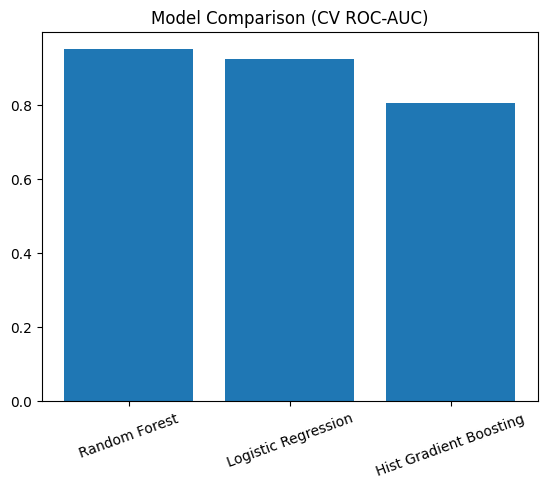

In [8]:
plt.figure()

plt.bar(cv_df.index, cv_df["CV ROC-AUC"])
plt.title("Model Comparison (CV ROC-AUC)")
plt.xticks(rotation=20)

plt.show()

In [9]:
results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    results[name] = auc
    trained_models[name] = model

    print(name, "Test ROC-AUC:", round(auc, 4))

Logistic Regression Test ROC-AUC: 0.9749
Random Forest Test ROC-AUC: 0.9868
Hist Gradient Boosting Test ROC-AUC: 0.8454


In [10]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

y_proba = best_model.predict_proba(X_test)[:, 1]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1 = (2 * precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thresholds[max(best_idx - 1, 0)]

y_pred = (y_proba >= best_threshold).astype(int)

print("Best Threshold:", best_threshold)

Best Threshold: 0.4346191900308623


In [12]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("True Negatives:", tn)

False Positives: 17
False Negatives: 17
True Positives: 81
True Negatives: 56847


In [13]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Precision: 0.8265
Recall: 0.8265
ROC-AUC: 0.9868368351842707


In [14]:
risk_score = (y_proba * 100).astype(int)

results_df = pd.DataFrame({
    "Actual": y_test,
    "Fraud_Probability": y_proba,
    "Risk_Score": risk_score,
    "Prediction": y_pred
})

results_df.head()

,Actual,Fraud_Probability,Risk_Score,Prediction
263020,0,0.000141,0,0
11378,0,0.003758,0,0
147283,0,0.016902,1,0
219439,0,0.001452,0,0
36939,0,0.080298,8,0


In [15]:
def risk_level(score):
    if score < 30:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

results_df["Risk_Level"] = results_df["Risk_Score"].apply(risk_level)

results_df["Risk_Level"].value_counts()

Risk_Level
Low       56843
High         81
Medium       38
Name: count, dtype: int64

In [16]:
tn, fp, fn, tp = cm.ravel()

cost_fp = 5
cost_fn = 50

fp_cost = fp * cost_fp
fn_cost = fn * cost_fn

total_cost = fp_cost + fn_cost

avg_cost_per_transaction = total_cost / len(y_test)

print(fp)
print(fn)
print(fp_cost)
print(fn_cost)
print(total_cost)
print(avg_cost_per_transaction)

17
17
85
850
935
0.01641445173975633


In [17]:
print("=== FRAUD MONITORING DASHBOARD ===")

print("\nTotal Transactions:", len(results_df))
print("High Risk:", (results_df["Risk_Level"] == "High").sum())
print("Medium Risk:", (results_df["Risk_Level"] == "Medium").sum())
print("Low Risk:", (results_df["Risk_Level"] == "Low").sum())

print("\nModel Performance Summary")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

=== FRAUD MONITORING DASHBOARD ===

Total Transactions: 56962
High Risk: 81
Medium Risk: 38
Low Risk: 56843

Model Performance Summary
ROC-AUC: 0.9868
Precision: 0.8265
Recall: 0.8265


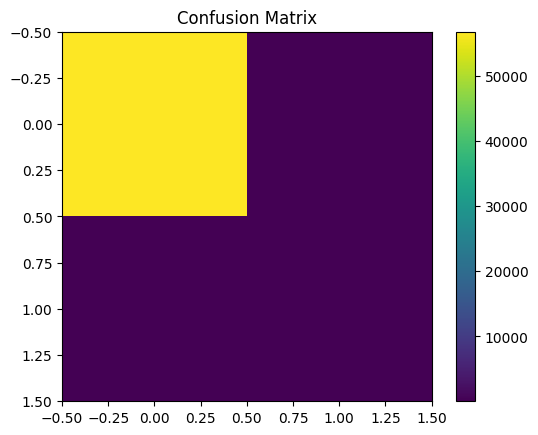

In [18]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

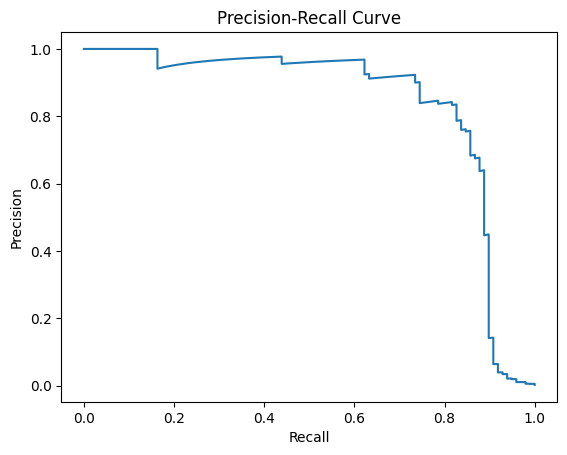

In [19]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [20]:
results_df.to_csv("fraud_predictions.csv", index=False)

model_summary = pd.DataFrame.from_dict(results, orient="index", columns=["ROC-AUC"])
model_summary.to_csv("model_summary.csv")

cost_report = pd.DataFrame([{
    "False_Positives": fp,
    "False_Negatives": fn,
    "False_Positive_Cost": fp_cost,
    "False_Negative_Cost": fn_cost,
    "Total_Cost": total_cost,
    "Avg_Cost_Per_Transaction": avg_cost_per_transaction
}])

cost_report.to_csv("cost_analysis.csv", index=False)

risk_summary = results_df["Risk_Level"].value_counts().reset_index()
risk_summary.columns = ["Risk_Level", "Count"]
risk_summary.to_csv("risk_distribution.csv", index=False)

# Conclusion — Fraud Detection System

This project successfully built a production-style fraud detection system using machine learning.

Key outcomes:
- Strong model performance (ROC-AUC ≈ 0.99)
- Balanced fraud detection (Precision ≈ 0.83, Recall ≈ 0.83)
- Effective risk segmentation (Low / Medium / High)
- Cost-aware evaluation of fraud impact
- Threshold-tuned decision system for real-world use

The final system goes beyond classification, acting as a full fraud risk engine capable of supporting real-time financial decision-making.